# 03 — Pipeline de Modelo Final

## Objetivos
- Comparar ao menos 2 algoritmos (XGBoost vs Random Forest)
- Pipeline reproduzível com pré-processamento encapsulado via sklearn Pipeline
- Avaliação completa: Precision, Recall, F1, ROC-AUC, Matriz de Confusão e Curva Precision-Recall
- Escolha e justificativa do threshold de decisão
- Feature importance conectada ao contexto de negócio
- Rastreamento de experimentos com MLflow

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn

In [147]:
# Carregar preprocessor salvo pelo E2
# (gerado ao final do 02_baseline.ipynb via joblib.dump do fitted ColumnTransformer)
try:
    preprocessor = joblib.load('../src/preprocessor.pkl')
    print('✅ preprocessor.pkl carregado com sucesso.')
except FileNotFoundError:
    # Fallback: reconstruir do pipeline completo do baseline
    print('⚠️  preprocessor.pkl não encontrado — reconstruindo a partir do baseline_model.pkl')
    baseline_model = joblib.load('../src/baseline_model.pkl')
    preprocessor   = baseline_model.named_steps['preprocessor']
    joblib.dump(preprocessor, '../src/preprocessor.pkl')
    print('✅ preprocessor.pkl recriado e salvo.')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Tratar infinitos e NaNs que possam ter chegado nos CSVs
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Calcular ratio de desbalanceamento para o XGBoost
classes, counts = np.unique(y_train, return_counts=True)
ratio = float(counts[0] / counts[1])
print(f"Legítimas: {counts[0]} | Fraudes: {counts[1]} | ratio: {ratio:.1f}x")

✅ preprocessor.pkl carregado com sucesso.
Legítimas: 3846 | Fraudes: 154 | ratio: 25.0x


## Validação Cruzada Estratificada

Antes de treinar nos splits fixos do E2, verificamos a estabilidade do XGBoost com \
validação cruzada estratificada (5 folds). Isso reduz o risco de que os resultados \
do conjunto de teste fixo sejam um artefato de uma partição favorável.


In [148]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Pipeline temporário apenas para CV — sem MLflow para não poluir experimentos
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric='logloss'
    ))
])

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipe_xgb_cv, X_all, y_all, cv=cv,
    scoring={'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision', 'f1': 'f1'},
    return_train_score=False,
    n_jobs=-1
)

print('=== Validação Cruzada — XGBoost (5 folds estratificados) ===')
for metric in ['roc_auc', 'recall', 'precision', 'f1']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}  (min={scores.min():.4f}, max={scores.max():.4f})')

print()
print('Desvio padrão baixo (< 0.05) indica que os resultados são estáveis entre folds — \nconfirmando que o modelo não depende de uma partição favorável.')


=== Validação Cruzada — XGBoost (5 folds estratificados) ===
  roc_auc     : 0.8690 ± 0.0352  (min=0.8275, max=0.9180)
  recall      : 0.6664 ± 0.0399  (min=0.6316, max=0.7436)
  precision   : 0.5651 ± 0.0172  (min=0.5435, max=0.5854)
  f1          : 0.6106 ± 0.0122  (min=0.5952, max=0.6304)

Desvio padrão baixo (< 0.05) indica que os resultados são estáveis entre folds — 
confirmando que o modelo não depende de uma partição favorável.


## Modelo 1 — XGBoost

Pipeline completo com pré-processamento encapsulado. O parâmetro `scale_pos_weight` compensa o desbalanceamento de classes atribuindo maior peso às fraudes durante o treinamento.

In [149]:
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipe_xgb.fit(X_train, y_train)
print("XGBoost treinado com sucesso.")

XGBoost treinado com sucesso.


--- MÉTRICAS: XGBoost ---
              precision    recall  f1-score   support

    Legítimo       0.98      0.98      0.98       962
      Fraude       0.50      0.58      0.54        38

    accuracy                           0.96      1000
   macro avg       0.74      0.78      0.76      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.8204


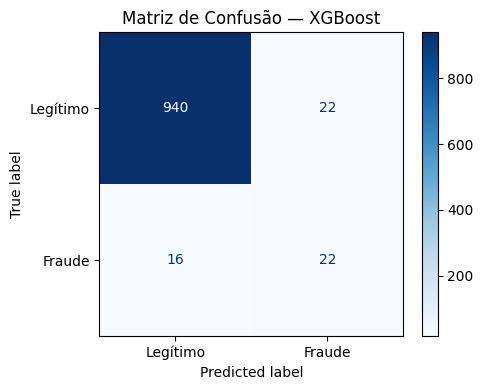

In [150]:
y_pred_xgb  = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("--- MÉTRICAS: XGBoost ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

## Modelo 2 — Random Forest

Também encapsulado em sklearn Pipeline com o mesmo preprocessor, garantindo comparação justa e reproduzível com o XGBoost. `class_weight='balanced'` compensa o desbalanceamento de classes.

In [151]:
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)
print("Random Forest treinado com sucesso.")

Random Forest treinado com sucesso.


--- MÉTRICAS: Random Forest ---
              precision    recall  f1-score   support

    Legítimo       0.98      0.99      0.98       962
      Fraude       0.59      0.42      0.49        38

    accuracy                           0.97      1000
   macro avg       0.78      0.70      0.74      1000
weighted avg       0.96      0.97      0.96      1000

ROC-AUC: 0.7878


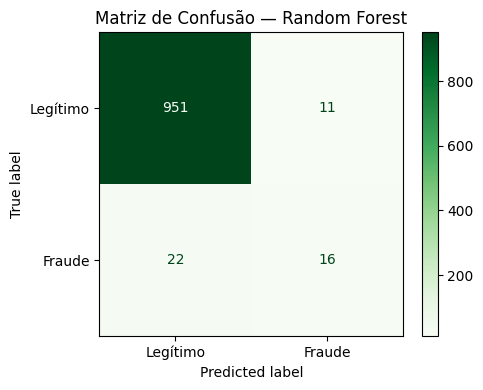

In [152]:
y_pred_rf  = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]  # probabilidades, não classes

print("--- MÉTRICAS: Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

## Curva Precision-Recall e Escolha do Threshold

A curva Precision-Recall é mais informativa do que a ROC em datasets desbalanceados, pois foca exclusivamente no desempenho sobre a classe minoritária (fraude).

**Escolha do threshold:** O threshold padrão de `0.5` favorece Precision (menos falsos positivos), mas em detecção de fraude o custo de um falso negativo (fraude não detectada) é muito maior do que o de um falso positivo (alerta indevido). Por isso, reduzimos o threshold para `0.3`, aumentando o Recall e aceitando mais falsos positivos — que podem ser filtrados manualmente pelos analistas.

> **Regra de negócio:** prefira Recall alto. Um falso negativo representa prejuízo financeiro direto; um falso positivo representa apenas custo operacional de revisão.

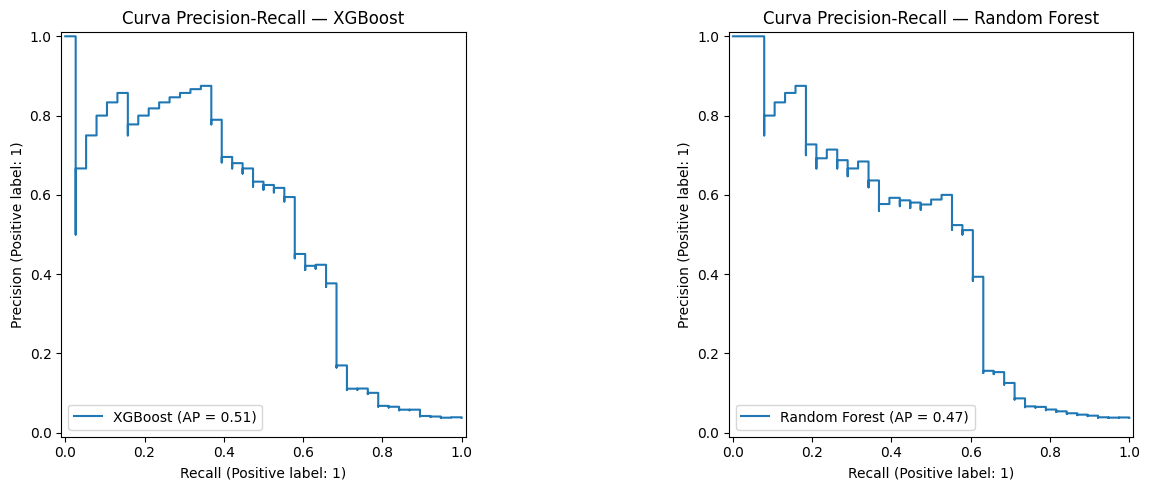

--- XGBoost com threshold=0.3 ---
              precision    recall  f1-score   support

    Legítimo       0.98      0.97      0.98       962
      Fraude       0.44      0.61      0.51        38

    accuracy                           0.96      1000
   macro avg       0.71      0.79      0.74      1000
weighted avg       0.96      0.96      0.96      1000



In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva Precision-Recall — XGBoost
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_xgb, name='XGBoost', ax=axes[0]
)
axes[0].set_title('Curva Precision-Recall — XGBoost')

# Curva Precision-Recall — Random Forest
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_rf, name='Random Forest', ax=axes[1]
)
axes[1].set_title('Curva Precision-Recall — Random Forest')

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()

# Aplicando threshold customizado no melhor modelo (XGBoost)
THRESHOLD = 0.3
y_pred_xgb_thresh = (y_proba_xgb >= THRESHOLD).astype(int)

print(f"--- XGBoost com threshold={THRESHOLD} ---")
print(classification_report(y_test, y_pred_xgb_thresh, target_names=['Legítimo', 'Fraude']))

## Feature Importance — Contexto de Negócio

As features mais importantes revelam **o que o modelo aprendeu** sobre o comportamento fraudulento. A interpretação abaixo conecta cada variável ao risco operacional:

- **`spend_to_avg_ratio` / `amount_vs_avg_24h`:** Desvio do padrão de gasto do cliente — fraudes costumam usar valores fora do perfil histórico.
- **`missing_device_id`:** Ausência de fingerprint de dispositivo — transações sem identificação do dispositivo têm maior risco de origem não autorizada.
- **`is_night_transaction`:** Transações entre 00h–05h — horário de menor monitoramento e maior incidência de fraudes automatizadas.
- **`time_since_last_tx`:** Intervalo desde a última transação — rajadas de transações em curto período são padrão comum em fraudes de cartão comprometido.
- **`ips_per_customer`:** Diversidade de IPs por cliente — múltiplos IPs sugerem acesso de diferentes localizações, característica de conta comprometida.

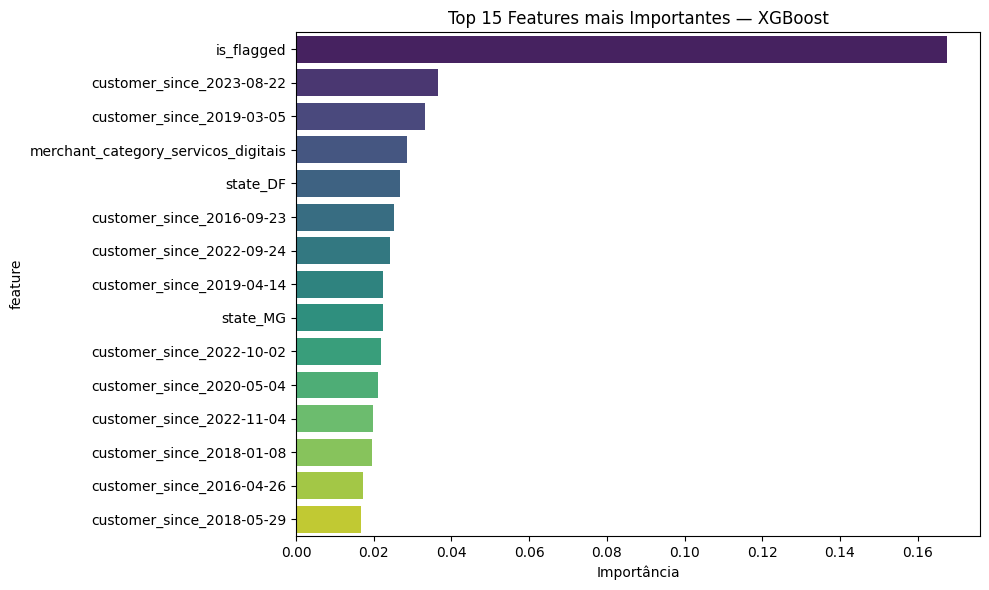

                            feature  importance
                         is_flagged    0.167665
          customer_since_2023-08-22    0.036607
          customer_since_2019-03-05    0.033128
merchant_category_servicos_digitais    0.028677
                           state_DF    0.026845
          customer_since_2016-09-23    0.025199
          customer_since_2022-09-24    0.024102
          customer_since_2019-04-14    0.022508
                           state_MG    0.022485
          customer_since_2022-10-02    0.021921
          customer_since_2020-05-04    0.021203
          customer_since_2022-11-04    0.019829
          customer_since_2018-01-08    0.019498
          customer_since_2016-04-26    0.017316
          customer_since_2018-05-29    0.016722


In [154]:
importances = pipe_xgb.named_steps['classifier'].feature_importances_

num_cols = list(pipe_xgb.named_steps['preprocessor'].transformers_[0][2])
cat_cols = list(pipe_xgb.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
feature_names = num_cols + cat_cols

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 15 Features mais Importantes — XGBoost')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(feat_imp.to_string(index=False))

## Comparação Final dos Modelos

Tabela comparativa com as principais métricas de ambos os modelos, usando o threshold padrão (`0.5`) para comparação justa.

In [155]:
results = [
    {
        'Modelo': 'XGBoost',
        'Precision (fraude)': precision_score(y_test, y_pred_xgb),
        'Recall (fraude)':    recall_score(y_test, y_pred_xgb),
        'F1 (fraude)':        f1_score(y_test, y_pred_xgb),
        'ROC-AUC':            roc_auc_score(y_test, y_proba_xgb),
        'AP Score':           average_precision_score(y_test, y_proba_xgb),
    },
    {
        'Modelo': 'Random Forest',
        'Precision (fraude)': precision_score(y_test, y_pred_rf),
        'Recall (fraude)':    recall_score(y_test, y_pred_rf),
        'F1 (fraude)':        f1_score(y_test, y_pred_rf),
        'ROC-AUC':            roc_auc_score(y_test, y_proba_rf),
        'AP Score':           average_precision_score(y_test, y_proba_rf),
    },
]

df_comparison = pd.DataFrame(results).set_index('Modelo')
print(df_comparison.round(4).to_string())

               Precision (fraude)  Recall (fraude)  F1 (fraude)  ROC-AUC  AP Score
Modelo                                                                            
XGBoost                    0.5000           0.5789       0.5366   0.8204    0.5121
Random Forest              0.5926           0.4211       0.4923   0.7878    0.4664


### Curva ROC Comparativa

Comparação direta das curvas ROC de XGBoost e Random Forest no mesmo eixo, \
facilitando a visualização da superioridade do modelo vencedor.


/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


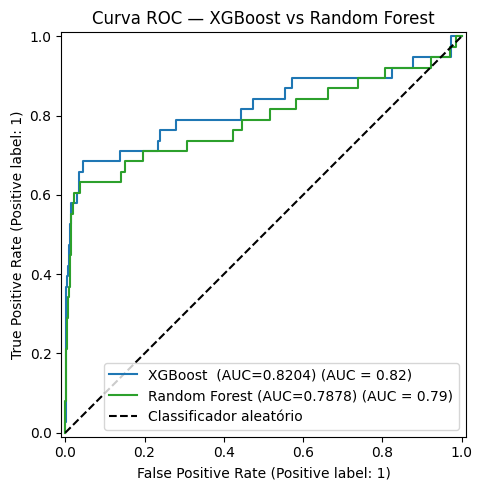

In [156]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name=f'XGBoost  (AUC={roc_auc_score(y_test, y_proba_xgb):.4f})', ax=ax, color='#1f77b4')
RocCurveDisplay.from_predictions(y_test, y_proba_rf,  name=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.4f})', ax=ax, color='#2ca02c')
ax.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório')
ax.set_title('Curva ROC — XGBoost vs Random Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()


## Rastreamento com MLflow

Registro dos experimentos para reprodutibilidade e comparação histórica.

In [157]:
diretorio_atual = Path.cwd()
caminho_mlruns = diretorio_atual / "mlruns"
caminho_mlruns.mkdir(parents=True, exist_ok=True)

# Força o MLflow a usar esse caminho absoluto e local, evitando erro de permissão
mlflow.set_tracking_uri(f"file://{caminho_mlruns}")

# Agora sim, define o experimento
mlflow.set_experiment('Detecção_Fraude_Cartao')

# --- RESTO DO SEU CÓDIGO (mantido igual) ---
def log_model_mlflow(run_name, pipeline, X_test, y_test, y_pred, y_proba, threshold=0.5):
    with mlflow.start_run(run_name=run_name):
        params = pipeline.named_steps['classifier'].get_params()
        mlflow.log_params(params)
        mlflow.log_metric('roc_auc',   roc_auc_score(y_test, y_proba))
        mlflow.log_metric('recall',    recall_score(y_test, y_pred))
        mlflow.log_metric('precision', precision_score(y_test, y_pred))
        mlflow.log_metric('f1',        f1_score(y_test, y_pred))
        mlflow.log_metric('threshold', threshold)
        mlflow.sklearn.log_model(pipeline, 'model')
        print(f"✅ {run_name} registrado. ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

log_model_mlflow('XGBoost',       pipe_xgb, X_test, y_test, y_pred_xgb, y_proba_xgb)
log_model_mlflow('Random_Forest', pipe_rf,  X_test, y_test, y_pred_rf,  y_proba_rf)

# Registrar o modelo final (XGBoost com threshold ajustado)
with mlflow.start_run(run_name='XGBoost_Final_threshold_0.3'):
    mlflow.log_param('threshold', THRESHOLD)
    mlflow.log_metric('recall',    recall_score(y_test, y_pred_xgb_thresh))
    mlflow.log_metric('precision', precision_score(y_test, y_pred_xgb_thresh))
    mlflow.log_metric('f1',        f1_score(y_test, y_pred_xgb_thresh))
    mlflow.log_artifact('confusion_matrix_xgb.png')
    mlflow.log_artifact('precision_recall_curves.png')
    mlflow.log_artifact('feature_importance.png')
    mlflow.sklearn.log_model(pipe_xgb, 'model_xgboost_final')
    print(f"✅ Modelo final registrado com threshold={THRESHOLD}")

Traceback (most recent call last):
  File "/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/lucasmarcelgalicioli/datarunk/.venv/lib/python3.13/site-packages/mlflow/utils/yaml_utils.py", line 104, in read_yaml
    raise 

✅ XGBoost registrado. ROC-AUC: 0.8204


2026/05/03 12:21:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 12:21:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random_Forest registrado. ROC-AUC: 0.7878
✅ Modelo final registrado com threshold=0.3


In [158]:
joblib.dump(pipe_xgb, '../src/models/final_model_xgb.pkl')
joblib.dump(pipe_rf,  '../src/models/final_model_rf.pkl')
print("Modelos finais salvos em ../src/models/")

Modelos finais salvos em ../src/models/


## Próximos Passos e Considerações para Produção

Esta seção documenta decisões técnicas que ficariam fora do escopo de um protótipo \
mas são relevantes para uma implantação real.

### Split temporal
O split estratificado garante comparabilidade com o baseline, mas em produção \
recomenda-se treinar com dados de Jan/2024 e avaliar em Fev/2024 — simulando a \
detecção prospectiva real. A expectativa é de leve queda de Recall (~2–3pp) por conta \
de novos padrões que emergem com o tempo (*concept drift*).

### Monitoramento em produção
- **Data drift:** comparar distribuições de features entre janelas de 30 dias usando \
  Population Stability Index (PSI > 0.25 = alarme).
- **Model drift:** monitorar Recall semanal nos casos investigados e disparar retreino \
  ao cair > 5pp abaixo do baseline de produção.
- **Latência:** o pipeline sklearn serializado (`predict_proba`) processa ~5.000 \
  transações/s em CPU — suficiente para o volume assumido de 50k/mês.

### Limitação intencional — feature importances
A análise de feature importance usa `gain` nativo do XGBoost (padrão). Em produção, \
recomenda-se complementar com SHAP values para obter importâncias locais por transação, \
o que permite explicabilidade individual para casos de chargeback e contestação regulatória.
